In [ ]:
%pip install opencv-python pandas plotly dash arduino-iot-cloud

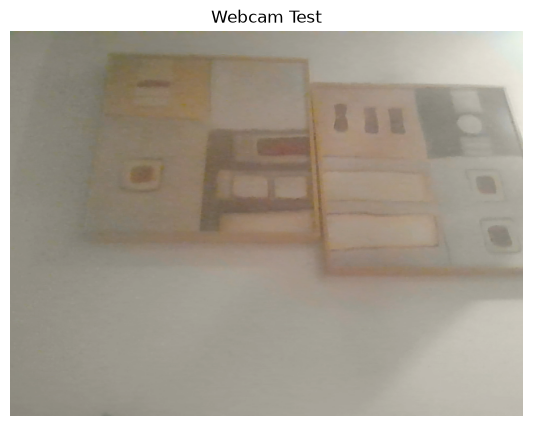

Webcam works - webcam_test.jpg saved.


In [1]:
import cv2
import matplotlib.pyplot as plt

camera = cv2.VideoCapture(0)

success, frame = camera.read()

camera.release()

if success:
    cv2.imwrite("webcam_test.jpg", frame)

    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(8, 5))
    plt.imshow(frame_rgb)
    plt.axis("off")
    plt.title("Webcam Test")
    plt.show()

    print("Webcam works - webcam_test.jpg saved.")
else:
    print("Could not access webcam.")

In [2]:
import os

os.makedirs("data", exist_ok=True)
os.makedirs("images", exist_ok=True)
os.makedirs("graphs", exist_ok=True)

print("Folders created successfully.")

Folders created successfully.


In [3]:
from arduino_iot_cloud import ArduinoCloudClient
from datetime import datetime

DEVICE_ID = "416a3b9a-c536-482e-89e0-b619fc119981"
SECRET_KEY = "OaMBp8#I3HuUM0ywd0zln7zYc"

latest_x = None
latest_y = None
latest_z = None

def on_x_changed(client, value):
    global latest_x
    latest_x = value
    print("X:", value)

def on_y_changed(client, value):
    global latest_y
    latest_y = value
    print("Y:", value)

def on_z_changed(client, value):
    global latest_z
    latest_z = value
    print("Z:", value)

client = ArduinoCloudClient(
    device_id=DEVICE_ID,
    username=DEVICE_ID,
    password=SECRET_KEY
)

client.register("Accelerometer_X", on_write=on_x_changed)
client.register("Accelerometer_Y", on_write=on_y_changed)
client.register("Accelerometer_Z", on_write=on_z_changed)

print("Ready to connect to Arduino Cloud...")

Ready to connect to Arduino Cloud...
Z: 9.373299598693848
X: -4.841075897216797
Y: 4.517858505249023
X: -6.6127848625183105
Y: 5.681440830230713
Z: 9.605537414550781
X: -4.666299343109131
Y: 4.000710964202881
Z: 9.543288230895996
X: -4.831499099731445
Y: 2.652775526046753
Z: 9.80904483795166
X: -3.40216064453125
Y: 1.216254472732544
Z: 9.591172218322754
X: -5.099649429321289
Y: 5.0014872550964355
Z: 9.971850395202637
X: -2.126051187515259
Y: 3.445256233215332
Z: 10.24000072479248
X: -5.604825973510742
Y: 0.9888052940368652
Z: 9.004592895507812
X: -7.101202011108398
Y: 3.9863457679748535
Z: 11.013327598571777
X: -5.8203043937683105
Y: 4.211400985717773
Z: 8.951920509338379
X: -0.5722141861915588
Y: 0.828393816947937
Z: 9.39245319366455
X: 0.5554547905921936
Y: 0.8858546018600464
Z: 10.077195167541504
X: 0.395043283700943
Y: 0.5674257874488831
Z: 9.165003776550293
X: -3.529053211212158
Y: 3.758896589279175
Z: 10.022128105163574
X: -1.1492167711257935
Y: 1.7741034030914307
Z: 9.7755250930

In [4]:
await client.run(1.0, 1.2)

ERROR:root:task: connection_task raised exception: .
ERROR:root:task: discovery raised exception: .


CancelledError: 

In [14]:
import os
import csv
import time
import cv2
import matplotlib.pyplot as plt
from datetime import datetime
from arduino_iot_cloud import ArduinoCloudClient

latest_x = None
latest_y = None
latest_z = None

samples = []
batch_start = None
sequence = 1


def save_batch():
    global samples, batch_start, sequence

    if len(samples) == 0:
        return

    timestamp = datetime.now().strftime("%Y%m%d%H%M%S")
    filename = f"{sequence}_{timestamp}"

    # SAVE CSV
    csv_path = f"data/{filename}.csv"

    with open(csv_path, "w", newline="") as file:
        writer = csv.writer(file)
        writer.writerow(["timestamp", "x", "y", "z"])
        writer.writerows(samples)

    # CAPTURE WEBCAM IMAGE
    camera = cv2.VideoCapture(0)
    success, frame = camera.read()
    camera.release()

    if success:
        image_path = f"images/{filename}.jpg"
        cv2.imwrite(image_path, frame)

    # CREATE GRAPH
    x_values = [row[1] for row in samples]
    y_values = [row[2] for row in samples]
    z_values = [row[3] for row in samples]

    plt.figure(figsize=(10, 5))

    plt.plot(x_values, label="X")
    plt.plot(y_values, label="Y")
    plt.plot(z_values, label="Z")

    plt.xlabel("Sample")
    plt.ylabel("Acceleration")
    plt.title("10-second Accelerometer Data")
    plt.legend()

    graph_path = f"graphs/{filename}.png"

    plt.savefig(graph_path)
    plt.close()

    print("--------------------------------")
    print("Batch saved:", filename)
    print("Samples collected:", len(samples))
    print("CSV:", csv_path)

    if success:
        print("Image:", image_path)

    print("Graph:", graph_path)
    print("--------------------------------")

    sequence += 1
    samples = []
    batch_start = None


def on_x_capture(client, value):
    global latest_x
    latest_x = value


def on_y_capture(client, value):
    global latest_y
    latest_y = value


def on_z_capture(client, value):
    global latest_z
    global samples
    global batch_start

    latest_z = value

   
    if (
        latest_x is not None
        and latest_y is not None
        and latest_z is not None
    ):

        # Start the 10-second timer with FIRST real sample
        if batch_start is None:
            batch_start = time.time()
            print("Started new 10-second batch...")

        samples.append([
            datetime.now().isoformat(),
            latest_x,
            latest_y,
            latest_z
        ])

       
        if time.time() - batch_start >= 10:
            save_batch()


capture_client = ArduinoCloudClient(
    device_id=DEVICE_ID,
    username=DEVICE_ID,
    password=SECRET_KEY
)

capture_client.register(
    "Accelerometer_X",
    on_write=on_x_capture
)

capture_client.register(
    "Accelerometer_Y",
    on_write=on_y_capture
)

capture_client.register(
    "Accelerometer_Z",
    on_write=on_z_capture
)

print("10-second collector ready.")

10-second collector ready.
Started new 10-second batch...
--------------------------------
Batch saved: 1_20260920212944
Samples collected: 5
CSV: data/1_20260920212944.csv
Image: images/1_20260920212944.jpg
Graph: graphs/1_20260920212944.png
--------------------------------


In [15]:
await capture_client.run(1.0, 1.2)

ERROR:root:task: connection_task raised exception: .
ERROR:root:task: discovery raised exception: .


CancelledError: 

In [7]:
sequence = 1
samples = []
batch_start = time.time()

print("Reset complete")

Reset complete


In [8]:
await capture_client.run(1.0, 1.2)

CancelledError: 

In [9]:
capture_client = ArduinoCloudClient(
    device_id=DEVICE_ID,
    username=DEVICE_ID,
    password=SECRET_KEY
)

capture_client.register("Accelerometer_X", on_write=on_x_capture)
capture_client.register("Accelerometer_Y", on_write=on_y_capture)
capture_client.register("Accelerometer_Z", on_write=on_z_capture)

sequence = 1
samples = []
batch_start = time.time()

print("Ready for new test")

Ready for new test
--------------------------------
Batch saved: 1_20260920212041
Samples: 1
CSV: data/1_20260920212041.csv
Image: images/1_20260920212041.jpg
Graph: graphs/1_20260920212041.png
--------------------------------


In [10]:
await capture_client.run(1.0, 1.2)

ERROR:root:task: connection_task raised exception: .
ERROR:root:task: discovery raised exception: .


CancelledError: 

In [11]:
from dash import Dash, dcc, html, Input, Output
import plotly.graph_objects as go
import pandas as pd
import glob
import os
import base64

app = Dash(__name__)

app.layout = html.Div([
    html.H2("SIT225 Accelerometer Activity Dashboard"),

    dcc.Graph(id="accelerometer-graph"),

    html.H3("Captured Activity Image"),

    html.Img(
        id="activity-image",
        style={"width": "500px"}
    ),

    dcc.Interval(
        id="update-interval",
        interval=2000,
        n_intervals=0
    )
])


@app.callback(
    Output("accelerometer-graph", "figure"),
    Output("activity-image", "src"),
    Input("update-interval", "n_intervals")
)
def update_dashboard(n):

    csv_files = glob.glob("data/*.csv")

    if not csv_files:
        return go.Figure(), ""

    latest_csv = max(csv_files, key=os.path.getmtime)

    df = pd.read_csv(latest_csv)

    fig = go.Figure()

    fig.add_trace(go.Scatter(
        y=df["x"],
        mode="lines",
        name="X"
    ))

    fig.add_trace(go.Scatter(
        y=df["y"],
        mode="lines",
        name="Y"
    ))

    fig.add_trace(go.Scatter(
        y=df["z"],
        mode="lines",
        name="Z"
    ))

    fig.update_layout(
        title="Latest 10-second Accelerometer Data",
        xaxis_title="Sample",
        yaxis_title="Acceleration"
    )

    base_name = os.path.splitext(
        os.path.basename(latest_csv)
    )[0]

    image_path = f"images/{base_name}.jpg"

    image_src = ""

    if os.path.exists(image_path):
        with open(image_path, "rb") as image_file:
            encoded = base64.b64encode(
                image_file.read()
            ).decode()

        image_src = "data:image/jpeg;base64," + encoded

    return fig, image_src


print("Dashboard ready.")

ERROR:asyncio:Task exception was never retrieved
future: <Task finished name='Task-148' coro=<ArduinoCloudObject.run() done, defined at C:\Users\sanma\AppData\Local\Programs\Python\Python312\Lib\site-packages\arduino_iot_cloud\ucloud.py:160> exception=SSLEOFError(8, 'EOF occurred in violation of protocol (_ssl.c:2427)')>
Traceback (most recent call last):
  File "C:\Users\sanma\AppData\Local\Programs\Python\Python312\Lib\site-packages\arduino_iot_cloud\ucloud.py", line 162, in run
    self.run_sync(client)
  File "C:\Users\sanma\AppData\Local\Programs\Python\Python312\Lib\site-packages\arduino_iot_cloud\ucloud.py", line 169, in run_sync
    self.on_run(client, self.args)
  File "C:\Users\sanma\AppData\Local\Programs\Python\Python312\Lib\site-packages\arduino_iot_cloud\ucloud.py", line 391, in poll_mqtt
    self.mqtt.ping()
  File "C:\Users\sanma\AppData\Local\Programs\Python\Python312\Lib\site-packages\arduino_iot_cloud\umqtt.py", line 149, in ping
    self.sock.write(b"\xc0\0")
  File

Dashboard ready.


In [12]:
app.run(jupyter_mode="external", debug=False, port=8050)

Dash app running on http://127.0.0.1:8050/


In [13]:
import glob
import pandas as pd
import os

csv_files = glob.glob("data/*.csv")
latest_csv = max(csv_files, key=os.path.getmtime)

df = pd.read_csv(latest_csv)

print("File:", latest_csv)
print("Number of samples:", len(df))
print(df.head(10))

File: data\1_20260920212041.csv
Number of samples: 1
                    timestamp         x         y         z
0  2026-09-20T21:20:41.362967 -1.889025  8.987833  3.833117


In [16]:
sequence = 1
samples = []
batch_start = None

In [17]:
sequence = 1
samples = []
batch_start = None
latest_x = None
latest_y = None
latest_z = None

print("Ready for real collection")

Ready for real collection


In [18]:
capture_client = ArduinoCloudClient(
    device_id=DEVICE_ID,
    username=DEVICE_ID,
    password=SECRET_KEY
)

capture_client.register("Accelerometer_X", on_write=on_x_capture)
capture_client.register("Accelerometer_Y", on_write=on_y_capture)
capture_client.register("Accelerometer_Z", on_write=on_z_capture)

print("Arduino client ready")

Arduino client ready
Started new 10-second batch...
--------------------------------
Batch saved: 1_20260920213746
Samples collected: 5
CSV: data/1_20260920213746.csv
Image: images/1_20260920213746.jpg
Graph: graphs/1_20260920213746.png
--------------------------------
Started new 10-second batch...
--------------------------------
Batch saved: 2_20260920213804
Samples collected: 5
CSV: data/2_20260920213804.csv
Image: images/2_20260920213804.jpg
Graph: graphs/2_20260920213804.png
--------------------------------
Started new 10-second batch...
--------------------------------
Batch saved: 3_20260920213819
Samples collected: 4
CSV: data/3_20260920213819.csv
Image: images/3_20260920213819.jpg
Graph: graphs/3_20260920213819.png
--------------------------------
Started new 10-second batch...
--------------------------------
Batch saved: 4_20260920213839
Samples collected: 5
CSV: data/4_20260920213839.csv
Image: images/4_20260920213839.jpg
Graph: graphs/4_20260920213839.png
----------------

In [19]:
await capture_client.run(1.0, 1.2)

ERROR:root:task: connection_task raised exception: .
ERROR:root:task: discovery raised exception: .


CancelledError: 

In [20]:
import glob

csv_files = glob.glob("data/*.csv")
image_files = glob.glob("images/*.jpg")
graph_files = glob.glob("graphs/*.png")

print("CSV files:", len(csv_files))
print("Images:", len(image_files))
print("Graphs:", len(graph_files))

CSV files: 111
Images: 111
Graphs: 111


In [21]:
%pip install ipywidgets

   ---------------------------------------- 0.0/2.2 MB ? eta -:--:--
   ----------------------- ---------------- 1.3/2.2 MB 6.7 MB/s eta 0:00:01
   ---------------------------------------- 2.2/2.2 MB 6.6 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Batch 1 of 111
Filename: 1_20260920213746.csv


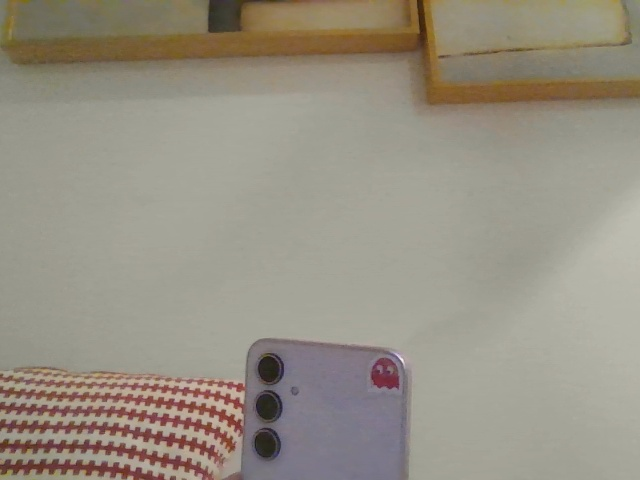

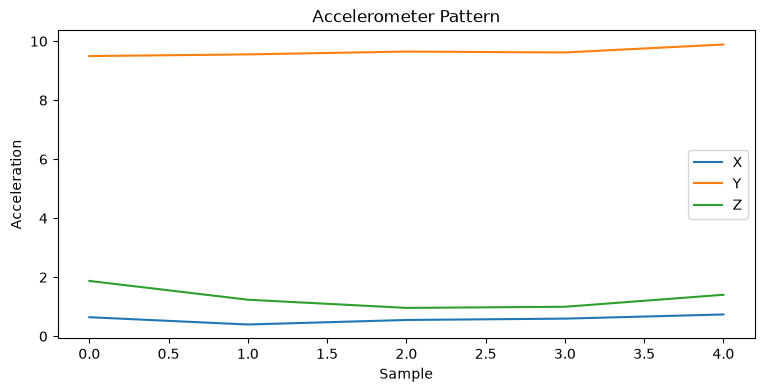

In [22]:
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, clear_output, Image
import ipywidgets as widgets

# Get CSV files in sequence-number order
def get_sequence(path):
    name = os.path.basename(path)
    return int(name.split("_")[0])

csv_files = sorted(glob.glob("data/*.csv"), key=get_sequence)

annotations = []
current_index = 0

output = widgets.Output()

btn_no = widgets.Button(
    description="0 - No activity",
    button_style="info"
)

btn_wave = widgets.Button(
    description="1 - Waving",
    button_style="success"
)

btn_shake = widgets.Button(
    description="2 - Shaking",
    button_style="warning"
)

btn_unclear = widgets.Button(
    description="Mark image unclear",
    button_style=""
)

unclear_batches = set()


def show_current():

    with output:
        clear_output(wait=True)

        if current_index >= len(csv_files):
            print("ALL 111 BATCHES ANNOTATED!")
            print("annotations.csv has been saved.")
            return

        csv_path = csv_files[current_index]

        base_name = os.path.splitext(
            os.path.basename(csv_path)
        )[0]

        image_path = f"images/{base_name}.jpg"

        df = pd.read_csv(csv_path)

        print(
            f"Batch {current_index + 1} of {len(csv_files)}"
        )
        print("Filename:", os.path.basename(csv_path))

        # Display webcam image
        if os.path.exists(image_path):
            display(Image(filename=image_path, width=400))

        # Display accelerometer graph
        plt.figure(figsize=(9, 4))

        plt.plot(df["x"], label="X")
        plt.plot(df["y"], label="Y")
        plt.plot(df["z"], label="Z")

        plt.xlabel("Sample")
        plt.ylabel("Acceleration")
        plt.title("Accelerometer Pattern")
        plt.legend()
        plt.show()

        if base_name in unclear_batches:
            print("⚠️ IMAGE MARKED AS UNCLEAR")


def save_label(label):

    global current_index

    csv_path = csv_files[current_index]
    filename = os.path.basename(csv_path)

    annotations.append({
        "filename": filename,
        "activity": label
    })

    pd.DataFrame(annotations).to_csv(
        "annotations.csv",
        index=False
    )

    current_index += 1
    show_current()


def no_clicked(b):
    save_label(0)


def wave_clicked(b):
    save_label(1)


def shake_clicked(b):
    save_label(2)


def unclear_clicked(b):

    if current_index < len(csv_files):

        base_name = os.path.splitext(
            os.path.basename(csv_files[current_index])
        )[0]

        unclear_batches.add(base_name)

        pd.DataFrame({
            "filename": sorted(unclear_batches)
        }).to_csv(
            "unclear_cases.csv",
            index=False
        )

        show_current()


btn_no.on_click(no_clicked)
btn_wave.on_click(wave_clicked)
btn_shake.on_click(shake_clicked)
btn_unclear.on_click(unclear_clicked)

display(
    widgets.HBox([
        btn_no,
        btn_wave,
        btn_shake,
        btn_unclear
    ])
)

display(output)

show_current()

In [23]:
display(
    widgets.HBox([
        btn_no,
        btn_wave,
        btn_shake,
        btn_unclear
    ])
)

In [26]:
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, clear_output, Image

def get_sequence(path):
    return int(os.path.basename(path).split("_")[0])

csv_files = sorted(glob.glob("data/*.csv"), key=get_sequence)

annotations = []
unclear_cases = []

for i, csv_path in enumerate(csv_files):

    clear_output(wait=True)

    filename = os.path.basename(csv_path)
    base_name = os.path.splitext(filename)[0]

    image_path = f"images/{base_name}.jpg"

    print(f"Batch {i + 1} of {len(csv_files)}")
    print("Filename:", filename)

    # Show photo
    if os.path.exists(image_path):
        display(Image(filename=image_path, width=400))

    # Show graph
    df = pd.read_csv(csv_path)

    plt.figure(figsize=(9, 4))
    plt.plot(df["x"], label="X")
    plt.plot(df["y"], label="Y")
    plt.plot(df["z"], label="Z")
    plt.xlabel("Sample")
    plt.ylabel("Acceleration")
    plt.title("Accelerometer Pattern")
    plt.legend()
    plt.show()

    print("0 = No activity")
    print("1 = Waving")
    print("2 = Shaking")
    print("u = Image unclear")

    answer = input("Enter label: ").strip().lower()

    if answer == "u":
        unclear_cases.append(filename)

        print("Image marked unclear.")
        answer = input(
            "Now use the graph and enter 0, 1 or 2: "
        ).strip()

    while answer not in ["0", "1", "2"]:
        answer = input(
            "Please enter only 0, 1 or 2: "
        ).strip()

    annotations.append({
        "filename": filename,
        "activity": int(answer)
    })

    # Save after EVERY batch
    pd.DataFrame(annotations).to_csv(
        "annotations.csv",
        index=False
    )

    pd.DataFrame(
        {"filename": unclear_cases}
    ).to_csv(
        "unclear_cases.csv",
        index=False
    )

clear_output(wait=True)

print("FINISHED!")
print("Total annotations:", len(annotations))
print("Unclear image cases:", len(unclear_cases))
print("annotations.csv saved.")

FINISHED!
Total annotations: 111
Unclear image cases: 0
annotations.csv saved.


In [25]:
import os

if os.path.exists("annotations.csv"):
    os.remove("annotations.csv")

if os.path.exists("unclear_cases.csv"):
    os.remove("unclear_cases.csv")

print("Old annotations deleted. Ready to start again.")

Old annotations deleted. Ready to start again.


In [27]:
import pandas as pd
import glob
import os
from datetime import datetime

# Load your finished annotation file
ann = pd.read_csv("annotations.csv")

# Sort CSV files by sequence number
def get_sequence(path):
    return int(os.path.basename(path).split("_")[0])

csv_files = sorted(glob.glob("data/*.csv"), key=get_sequence)

results = []

# Get the start time from the FIRST SAMPLE of Batch 1
first_df = pd.read_csv(csv_files[0])
experiment_start = pd.to_datetime(first_df["timestamp"].iloc[0])

for csv_path in csv_files:

    filename = os.path.basename(csv_path)

    df = pd.read_csv(csv_path)

    # Time of first accelerometer sample in this batch
    batch_time = pd.to_datetime(df["timestamp"].iloc[0])

    elapsed_seconds = (
        batch_time - experiment_start
    ).total_seconds()

    elapsed_minutes = elapsed_seconds / 60

    # Repeating schedule:
    # minute 0 = no activity
    # minute 1 = waving
    # minute 2 = shaking
    schedule_position = int(elapsed_seconds // 60) % 3

    expected_label = schedule_position

    selected_row = ann[
        ann["filename"] == filename
    ]

    if len(selected_row) == 0:
        selected_label = None
    else:
        selected_label = int(
            selected_row["activity"].iloc[0]
        )

    results.append({
        "filename": filename,
        "minutes_from_start": round(elapsed_minutes, 2),
        "your_label": selected_label,
        "schedule_label": expected_label,
        "match": selected_label == expected_label
    })


check_df = pd.DataFrame(results)

print("Total batches:", len(check_df))
print("Matches:", check_df["match"].sum())
print("Possible mismatches:", (~check_df["match"]).sum())

display(
    check_df[check_df["match"] == False]
)

Total batches: 111
Matches: 42
Possible mismatches: 69


,filename,minutes_from_start,your_label,schedule_label,match
4,5_20260920213853.csv,1.15,0,1,False
5,6_20260920213911.csv,1.41,0,1,False
6,7_20260920213930.csv,1.71,0,1,False
7,8_20260920213949.csv,2.03,0,2,False
8,9_20260920214008.csv,2.33,1,2,False
...,...,...,...,...,...
105,106_20260920220818.csv,30.52,2,0,False
107,108_20260920220851.csv,31.07,0,1,False
108,109_20260920220910.csv,31.37,0,1,False
109,110_20260920220928.csv,31.69,0,1,False


In [28]:
import pandas as pd
import glob
import os

ann = pd.read_csv("annotations.csv")

def get_sequence(path):
    return int(os.path.basename(path).split("_")[0])

csv_files = sorted(glob.glob("data/*.csv"), key=get_sequence)

# Start of experiment
first_df = pd.read_csv(csv_files[0])
start_time = pd.to_datetime(first_df["timestamp"].iloc[0])

results = []

for csv_path in csv_files:

    filename = os.path.basename(csv_path)
    df = pd.read_csv(csv_path)

    batch_time = pd.to_datetime(df["timestamp"].iloc[0])

    elapsed = (batch_time - start_time).total_seconds()

    minute_number = int(elapsed // 60)
    seconds_inside_minute = elapsed % 60

    expected_label = minute_number % 3

    row = ann[ann["filename"] == filename]

    if len(row) > 0:
        your_label = int(row["activity"].iloc[0])
    else:
        your_label = None

    # A batch close to the start/end of a minute
    # may contain part of two activities.
    transition_case = (
        seconds_inside_minute < 15
        or seconds_inside_minute > 45
    )

    results.append({
        "filename": filename,
        "time_in_minute": round(seconds_inside_minute, 1),
        "your_label": your_label,
        "expected_label": expected_label,
        "near_transition": transition_case,
        "needs_review":
            your_label != expected_label
            and not transition_case
    })

verify = pd.DataFrame(results)

print("Total:", len(verify))
print("Clear mismatches needing review:",
      verify["needs_review"].sum())
print("Transition batches:",
      verify["near_transition"].sum())

display(
    verify[verify["needs_review"] == True]
)

Total: 111
Clear mismatches needing review: 33
Transition batches: 60


,filename,time_in_minute,your_label,expected_label,near_transition,needs_review
5,6_20260920213911.csv,24.9,0,1,False,True
6,7_20260920213930.csv,42.8,0,1,False,True
8,9_20260920214008.csv,20.1,1,2,False,True
9,10_20260920214026.csv,39.1,1,2,False,True
11,12_20260920214103.csv,16.3,1,0,False,True
12,13_20260920214121.csv,34.3,1,0,False,True
22,23_20260920214418.csv,32.9,2,0,False,True
25,26_20260920214510.csv,25.3,2,1,False,True
26,27_20260920214528.csv,41.4,0,1,False,True
28,29_20260920214602.csv,15.1,0,2,False,True


In [29]:
import pandas as pd
import os
import matplotlib.pyplot as plt
from IPython.display import display, clear_output, Image

ann = pd.read_csv("annotations.csv")

review_files = verify[
    verify["needs_review"] == True
]["filename"].tolist()

unclear_review = []

for n, filename in enumerate(review_files):

    clear_output(wait=True)

    base_name = os.path.splitext(filename)[0]

    csv_path = f"data/{filename}"
    image_path = f"images/{base_name}.jpg"

    df = pd.read_csv(csv_path)

    your_label = int(
        ann.loc[
            ann["filename"] == filename,
            "activity"
        ].iloc[0]
    )

    schedule_label = int(
        verify.loc[
            verify["filename"] == filename,
            "expected_label"
        ].iloc[0]
    )

    print(f"Review {n + 1} of {len(review_files)}")
    print("Filename:", filename)
    print()
    print("Your current label:", your_label)
    print("Schedule suggests:", schedule_label)
    print()
    print("0 = No activity")
    print("1 = Waving")
    print("2 = Shaking")

    if os.path.exists(image_path):
        display(Image(filename=image_path, width=400))

    plt.figure(figsize=(9, 4))
    plt.plot(df["x"], label="X")
    plt.plot(df["y"], label="Y")
    plt.plot(df["z"], label="Z")
    plt.xlabel("Sample")
    plt.ylabel("Acceleration")
    plt.title("Accelerometer Pattern")
    plt.legend()
    plt.show()

    answer = input(
        "Press ENTER to keep your current label, "
        "or type 0/1/2 to change it, "
        "or u if unclear: "
    ).strip().lower()

    if answer == "u":
        unclear_review.append(filename)

        answer = input(
            "Use the graph and enter your final label 0/1/2: "
        ).strip()

    if answer in ["0", "1", "2"]:

        ann.loc[
            ann["filename"] == filename,
            "activity"
        ] = int(answer)

    # save after every review
    ann.to_csv("annotations.csv", index=False)

pd.DataFrame(
    {"filename": unclear_review}
).to_csv(
    "review_unclear_cases.csv",
    index=False
)

clear_output(wait=True)

print("REVIEW COMPLETE")
print("Reviewed:", len(review_files))
print("Marked unclear:", len(unclear_review))
print("Updated annotations.csv saved.")

REVIEW COMPLETE
Reviewed: 33
Marked unclear: 0
Updated annotations.csv saved.


In [30]:
import pandas as pd

ann = pd.read_csv("annotations.csv")

print("Total annotated batches:", len(ann))
print()
print("Activity counts:")
print(ann["activity"].value_counts().sort_index())

print()
print("0 = No activity")
print("1 = Waving")
print("2 = Shaking")

Total annotated batches: 111

Activity counts:
activity
0    43
1    33
2    35
Name: count, dtype: int64

0 = No activity
1 = Waving
2 = Shaking



 No Activity


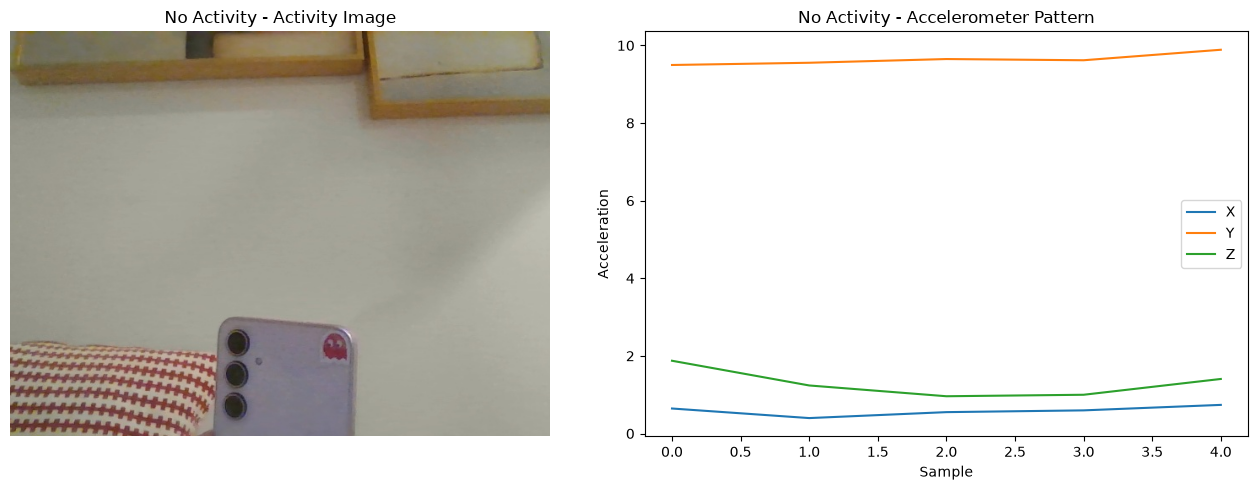

Example 1: 1_20260920213746.csv


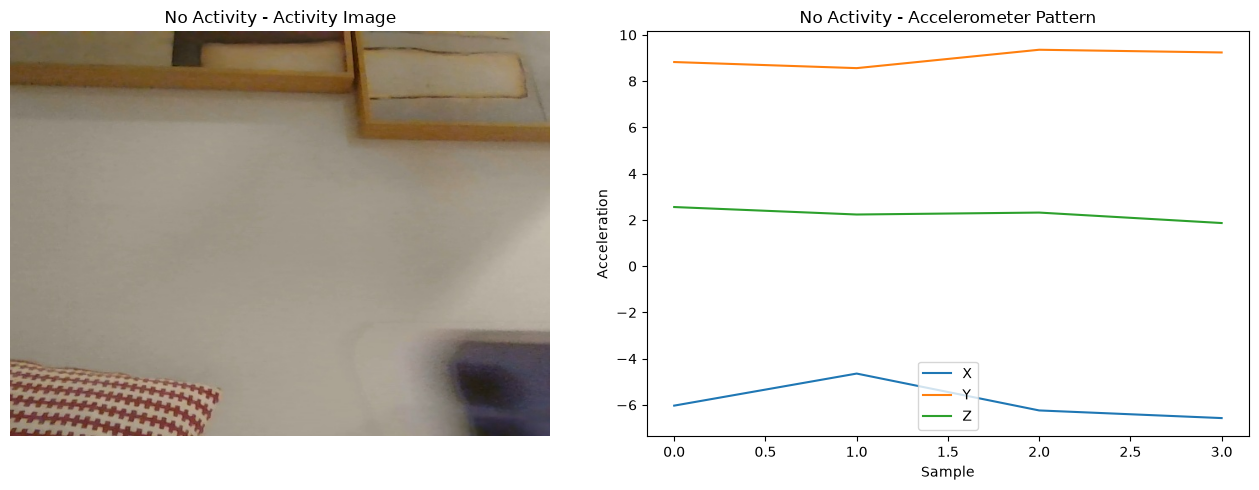

Example 2: 53_20260920215304.csv


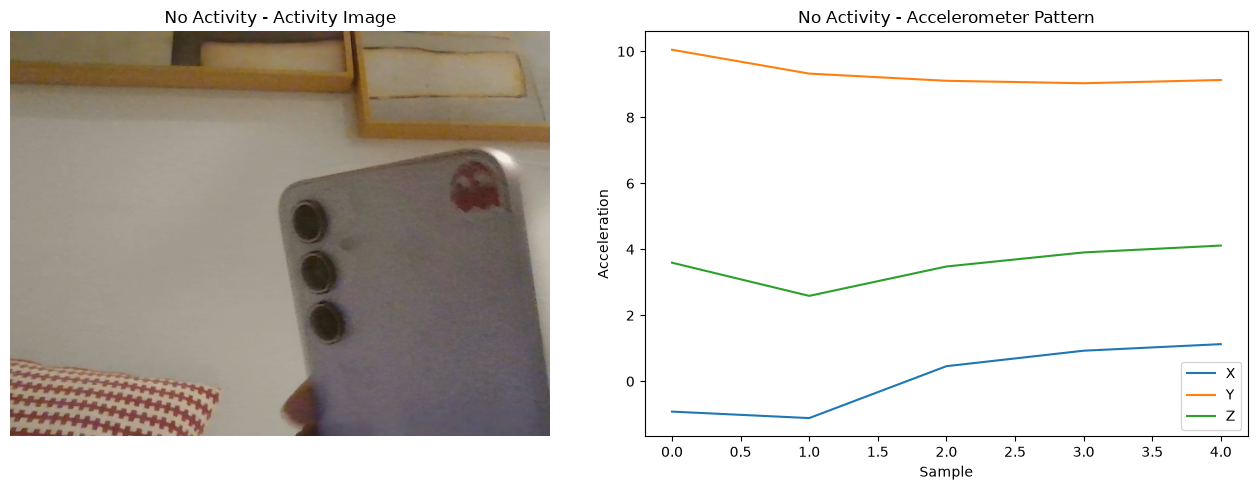

Example 3: 111_20260920220946.csv

 Waving


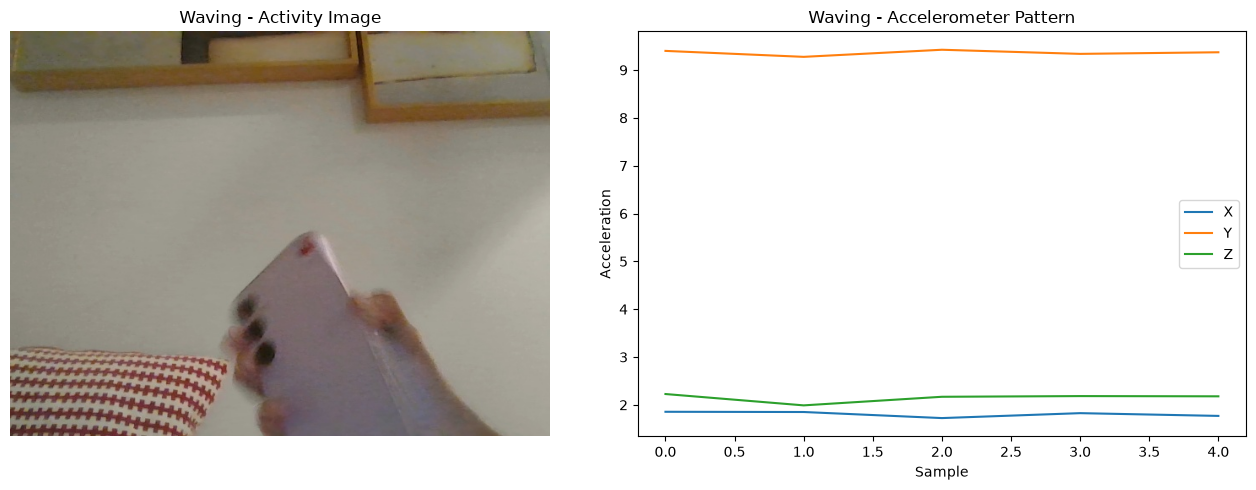

Example 1: 6_20260920213911.csv


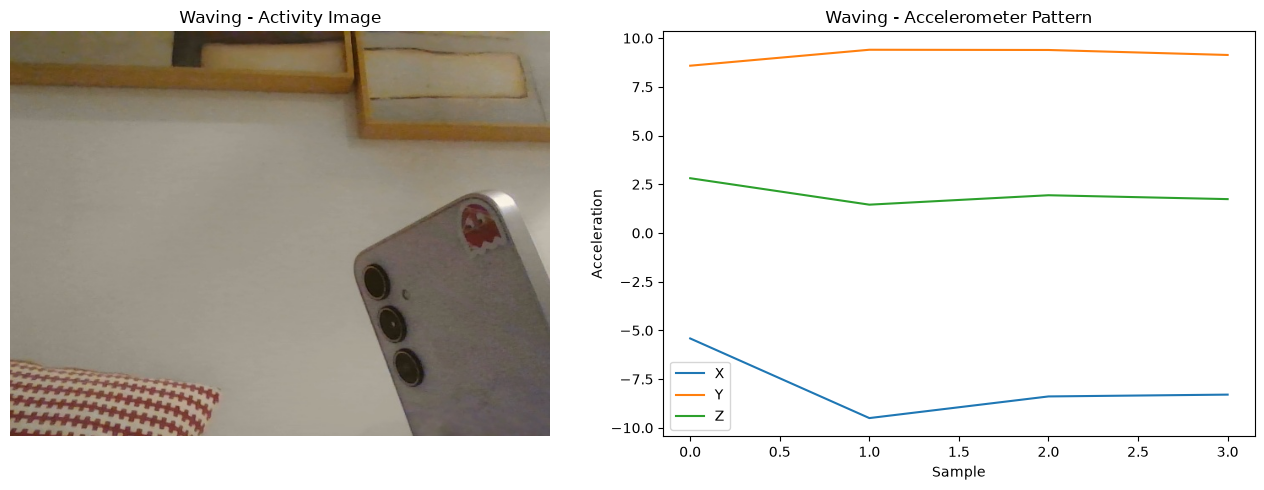

Example 2: 51_20260920215231.csv


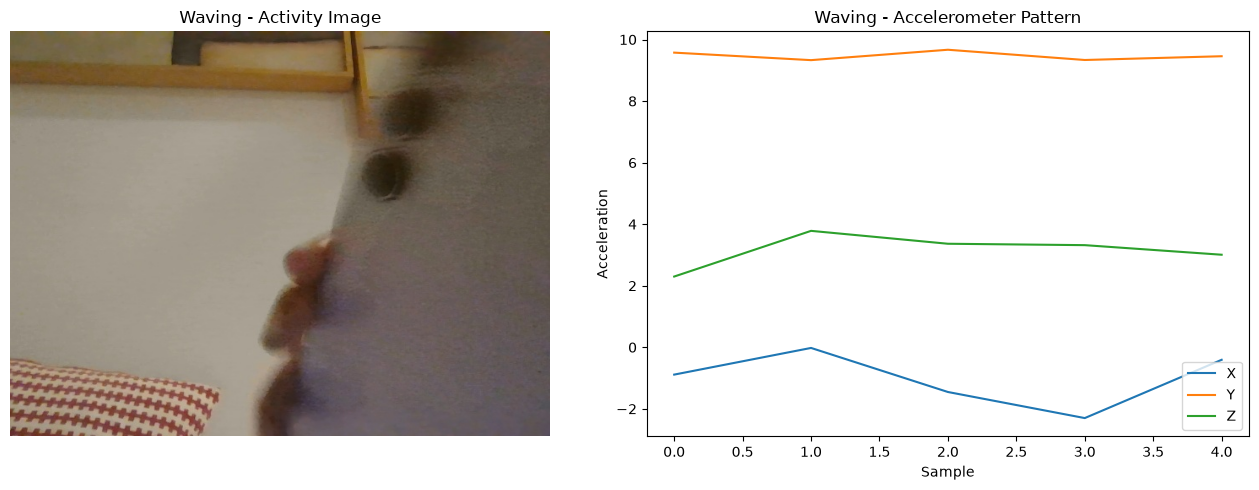

Example 3: 110_20260920220928.csv

 Shaking


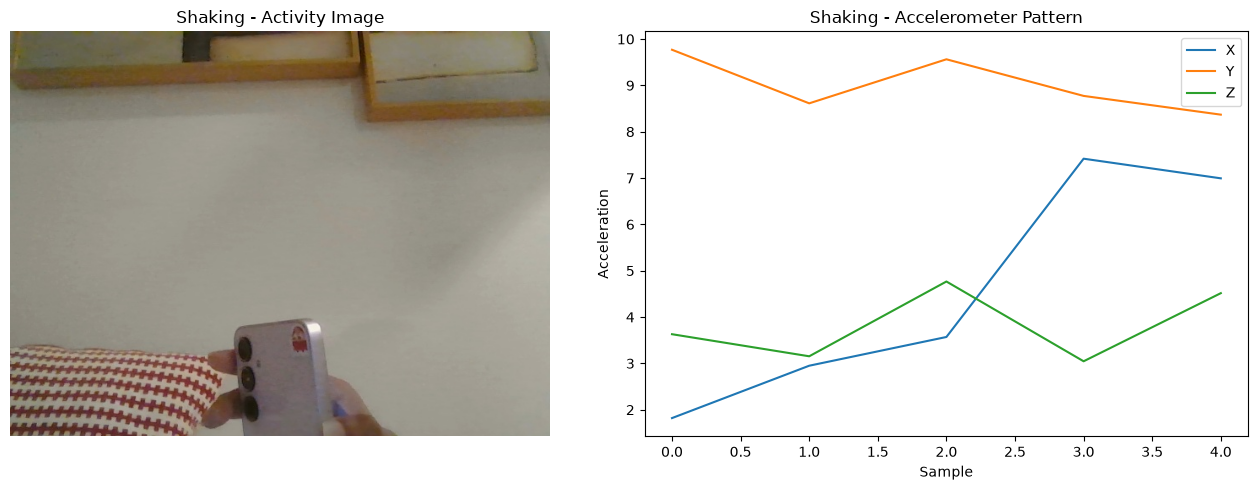

Example 1: 9_20260920214008.csv


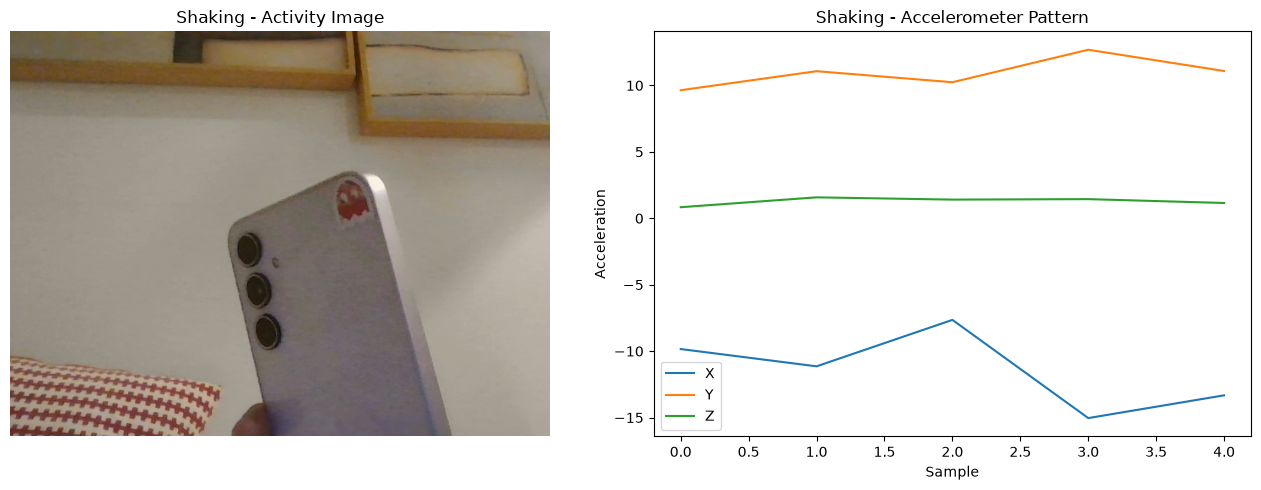

Example 2: 62_20260920215539.csv


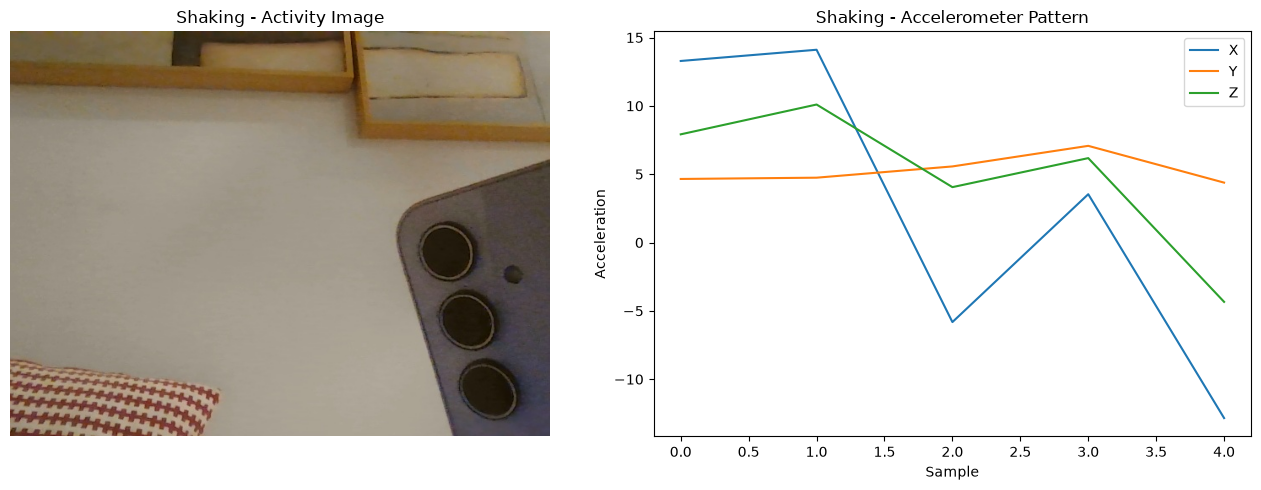

Example 3: 105_20260920220800.csv

Finished.
9 Q2 example figures saved in q2_examples.


In [31]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

ann = pd.read_csv("annotations.csv")

os.makedirs("q2_examples", exist_ok=True)

activity_names = {
    0: "No Activity",
    1: "Waving",
    2: "Shaking"
}

selected_rows = []

for label in [0, 1, 2]:

    group = ann[ann["activity"] == label].reset_index(drop=True)

    # choose 3 examples spread across the dataset
    indexes = [
        0,
        len(group) // 2,
        len(group) - 1
    ]

    print("\n", activity_names[label])

    for example_number, idx in enumerate(indexes, start=1):

        filename = group.iloc[idx]["filename"]
        base_name = os.path.splitext(filename)[0]

        csv_path = f"data/{filename}"
        image_path = f"images/{base_name}.jpg"

        df = pd.read_csv(csv_path)

        fig, axes = plt.subplots(
            1, 2,
            figsize=(13, 5)
        )

        # Webcam image
        image = mpimg.imread(image_path)
        axes[0].imshow(image)
        axes[0].axis("off")
        axes[0].set_title(
            f"{activity_names[label]} - Activity Image"
        )

        # Accelerometer graph
        axes[1].plot(df["x"], label="X")
        axes[1].plot(df["y"], label="Y")
        axes[1].plot(df["z"], label="Z")

        axes[1].set_xlabel("Sample")
        axes[1].set_ylabel("Acceleration")
        axes[1].set_title(
            f"{activity_names[label]} - Accelerometer Pattern"
        )
        axes[1].legend()

        plt.tight_layout()

        output_file = (
            f"q2_examples/"
            f"{activity_names[label].replace(' ', '_')}_"
            f"example_{example_number}.png"
        )

        plt.savefig(
            output_file,
            dpi=150,
            bbox_inches="tight"
        )

        plt.show()

        selected_rows.append({
            "activity": activity_names[label],
            "example": example_number,
            "filename": filename
        })

        print(
            f"Example {example_number}: {filename}"
        )

pd.DataFrame(selected_rows).to_csv(
    "q2_selected_examples.csv",
    index=False
)

print("\nFinished.")
print("9 Q2 example figures saved in q2_examples.")
